## APTED vs ZSS: mismo resultado, distinto tiempo

Verifica, sobre una muestra de pares de programas reales de los conjuntos de esta evaluación, que APTED y ZSS
calculan la misma distancia de edición entre los árboles normalizados y podados de csim, y compara cuánto tarda
cada uno. Es la base de la Figura 4.x del capítulo 4 (elección del algoritmo de distancia de edición).

**Muestra**: `N_PAIRS` pares, formados al azar (semilla fija) entre todos los archivos de los conjuntos A-F de
`../datasets`, sin excluir pares del mismo problema ni del mismo archivo consigo mismo (aquí solo interesa el
tiempo de cálculo sobre árboles de tamaño realista, no la similitud entre programas).

In [1]:
%matplotlib inline
import glob
import os
import random
import time

import matplotlib.pyplot as plt
import numpy as np

from csim.language.parser import ANTLR_parse
from csim.processing.tree_processing import Normalize, PruneAndHash
from csim.processing.distance_metrics import TreeEditDistance

DATASETS_DIR = os.path.join("..", "datasets")
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

SEED = 20260927
N_PAIRS = 300
LANG = "python_3"

### 1. Formar la muestra de pares y construir los árboles (una sola vez por archivo)

In [2]:
files = sorted(glob.glob(os.path.join(DATASETS_DIR, "*", "*.py")))
print(f"{len(files)} archivos .py disponibles en A-F")

rng = random.Random(SEED)
pairs = [(rng.choice(files), rng.choice(files)) for _ in range(N_PAIRS)]

_cache = {}


def tree(path):
    if path not in _cache:
        code = open(path, encoding="utf-8").read()
        raw = ANTLR_parse(path, code, LANG)
        norm = Normalize(raw, LANG)
        _cache[path] = PruneAndHash(norm, LANG)
    return _cache[path]


for a, b in pairs:
    tree(a)
    tree(b)
print(f"{len(_cache)} árboles distintos construidos para los {N_PAIRS} pares")

1332 archivos .py disponibles en A-F


478 árboles distintos construidos para los 300 pares


### 2. Calcular la distancia con cada algoritmo y medir el tiempo

In [3]:
results = {}
for algo in ("zss", "apted"):
    distances = []
    t0 = time.perf_counter()
    for a, b in pairs:
        pa, _ = tree(a)
        pb, _ = tree(b)
        distances.append(TreeEditDistance(pa, pb, ted_algorithm=algo))
    total = time.perf_counter() - t0
    results[algo] = {"distances": np.array(distances), "total": total}
    print(f"{algo:6s}: {total:6.2f} s para {N_PAIRS} pares ({N_PAIRS / total:6.1f} pares/s)")

diff = np.abs(results["zss"]["distances"] - results["apted"]["distances"])
print(f"\ndiferencia máxima entre las dos distancias: {diff.max():.2e} (redondeo de punto flotante)")
speedup = results["zss"]["total"] / results["apted"]["total"]
print(f"APTED es {speedup:.1f} veces más rápido que ZSS en esta muestra")

zss   :   9.42 s para 300 pares (  31.8 pares/s)


apted :   1.59 s para 300 pares ( 188.7 pares/s)

diferencia máxima entre las dos distancias: 0.00e+00 (redondeo de punto flotante)
APTED es 5.9 veces más rápido que ZSS en esta muestra


### 3. Figura: tiempo total y verificación de que ambos calculan la misma distancia

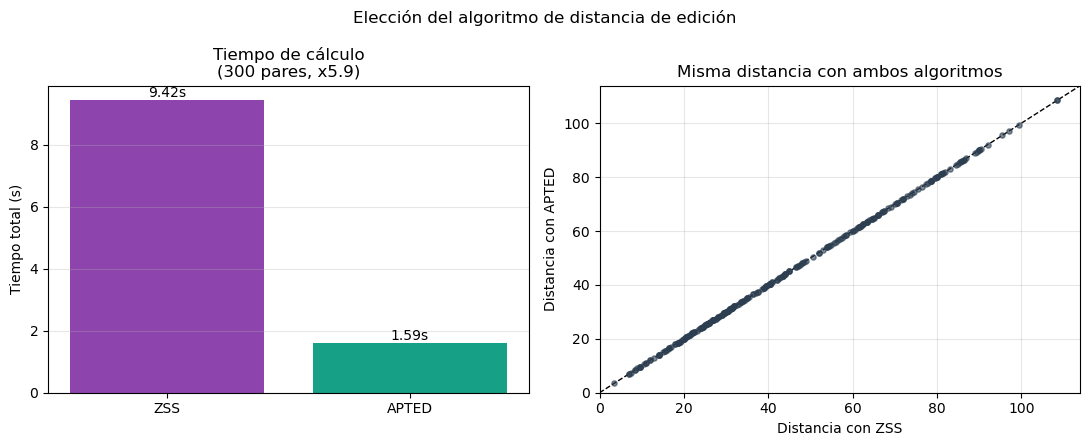

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

colors = {"zss": "#8e44ad", "apted": "#16a085"}
labels = {"zss": "ZSS", "apted": "APTED"}
bars = axes[0].bar([labels[a] for a in ("zss", "apted")],
                    [results[a]["total"] for a in ("zss", "apted")],
                    color=[colors[a] for a in ("zss", "apted")])
for b, a in zip(bars, ("zss", "apted")):
    axes[0].text(b.get_x() + b.get_width() / 2, b.get_height(), f"{results[a]['total']:.2f}s",
                 ha="center", va="bottom", fontsize=10)
axes[0].set_ylabel("Tiempo total (s)")
axes[0].set_title(f"Tiempo de cálculo\n({N_PAIRS} pares, x{speedup:.1f})")
axes[0].grid(axis="y", alpha=0.3)

lim = max(results["zss"]["distances"].max(), results["apted"]["distances"].max()) * 1.05
axes[1].plot([0, lim], [0, lim], color="black", linewidth=1, linestyle="--", zorder=1)
axes[1].scatter(results["zss"]["distances"], results["apted"]["distances"], s=14, alpha=0.6,
                 color="#2c3e50", zorder=2)
axes[1].set_xlabel("Distancia con ZSS")
axes[1].set_ylabel("Distancia con APTED")
axes[1].set_title("Misma distancia con ambos algoritmos")
axes[1].set_xlim(0, lim)
axes[1].set_ylim(0, lim)
axes[1].grid(alpha=0.3)

fig.suptitle("Elección del algoritmo de distancia de edición")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig_apted_vs_zss.png"), dpi=200, bbox_inches="tight")
plt.show()